# Loss vs. Combined Loss

Based on the [Loss Comparison Notebook](03_loss.ipynb), **ProxyAnchor Loss** performs best on our dataset with the current training pipeline (**DINOv3** backbone and blurred backgrounds). In this notebook, we compare **ProxyAnchor Loss** with a combined loss consisting of **ProxyAnchor Loss** and **Center Loss**. To further analyze the effect of combining losses, we also include a run using **ArcFaceLoss** together with **Center Loss**. For each loss combination, we train an **embedding projection model** and compare the resulting **identity-balanced mAP** on the validation set.

Training follows the same pipeline used in previous experiments, with the only change being the applied loss function. When combining losses, we control their relative contribution using a `lambda` parameter.

The notebook is structured as follows:

1. **ProxyAnchor Loss** (baseline)
2. **ProxyAnchor Loss + Center Loss**
3. **ArcFaceLoss + Center Loss**

## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters needed for the subsequent exploratory data analysis.

In [ ]:
EXPERIMENT_NAME = "04_loss_combined"
RANDOM_SEED = 123 # 3, 908, 45, 33, 123

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    ArcFaceLoss,
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset, ImageDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

For the configuration, we use the same parameters as in the [Loss Comparison Notebook](03_loss.ipynb), with the addition of a `lambda` parameter to control the contribution of each loss in the combined loss setting.


In [ ]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "arcface_lambda": 0.001,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  arcface_margin: 0.5
  arcface_scale: 64.0
  arcface_lambda: 0.001
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 123


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


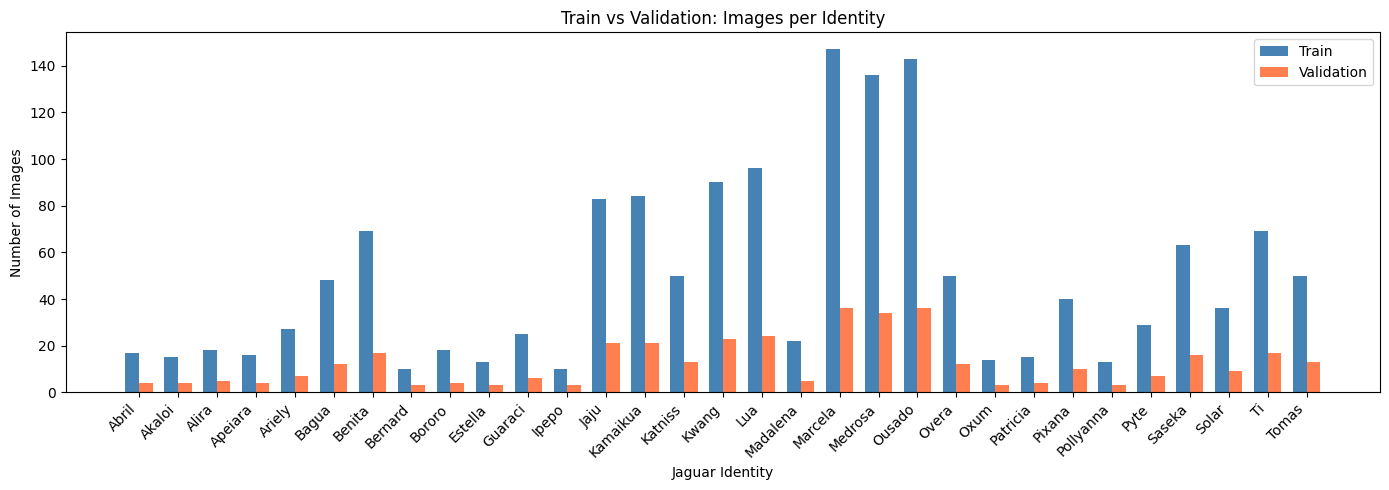


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [ ]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [ ]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


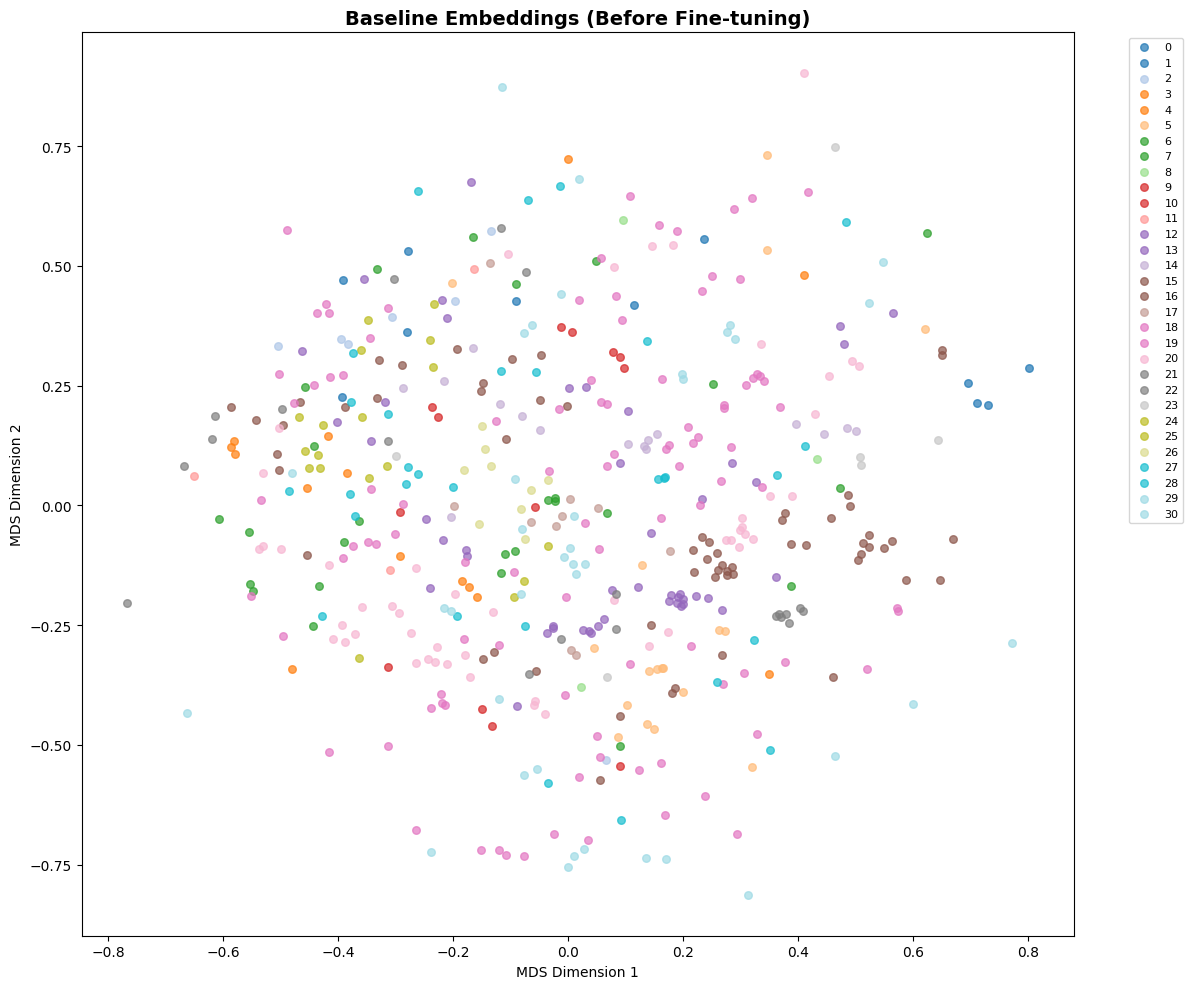

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


During comparison, we initialize each experiment with the same model weights to ensure that differences in performance are not influenced by variations in initialization.

In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss_combined/model_initial_weights.pth


In [ ]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch", "Training time"]
]

## Proxy Anchor Loss

**Proxy Anchor Loss** achieved the best performance as a single loss function in the [Loss Comparison Notebook](03_loss.ipynb).


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
proxy_anchor_checkpoint_path = CHECKPOINT_PATH / "best_proxyanchor_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor",
    checkpoint_path=proxy_anchor_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
    "training_time_proxyanchor": training_time
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.7821
  Val Loss:   7.9793
  Val mAP:    0.3262 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0205
  Val Loss:   7.6613
  Val mAP:    0.3279 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.5497
  Val Loss:   7.4499
  Val mAP:    0.3259 | LR: 1.00e-04
  No improvement. Patience: 1/10

Epoch 4/200


  Train Loss: 8.3373
  Val Loss:   7.3098
  Val mAP:    0.3268 | LR: 1.00e-04
  No improvement. Patience: 2/10

Epoch 5/200


...

  Train Loss: 0.2458
  Val Loss:   0.7647
  Val mAP:    0.8770 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 136/200


  Train Loss: 0.2294
  Val Loss:   0.7649
  Val mAP:    0.8810 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 137/200


  Train Loss: 0.2244
  Val Loss:   0.7629
  Val mAP:    0.8813 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 138/200


  Train Loss: 0.2273
  Val Loss:   0.7587
  Val mAP:    0.8818 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 139/200


  Train Loss: 0.2152
  Val Loss:   0.7603
  Val mAP:    0.8816 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 139 epochs

Training complete!
Best epoch: 129, Val mAP: 0.8822


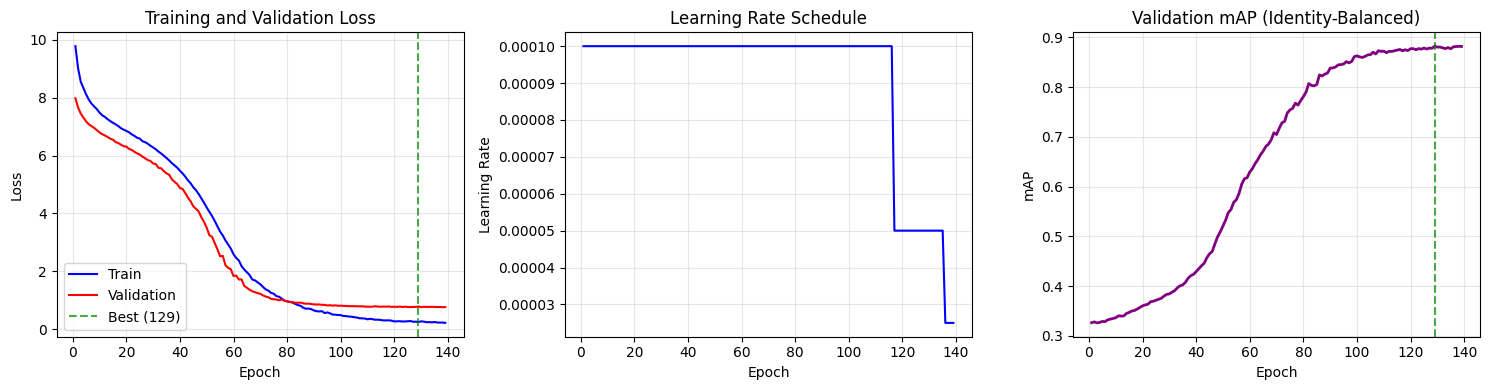

In [22]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(proxy_anchor_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 129
  Val Loss: 0.7788
  Val mAP: 0.8822


In [24]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


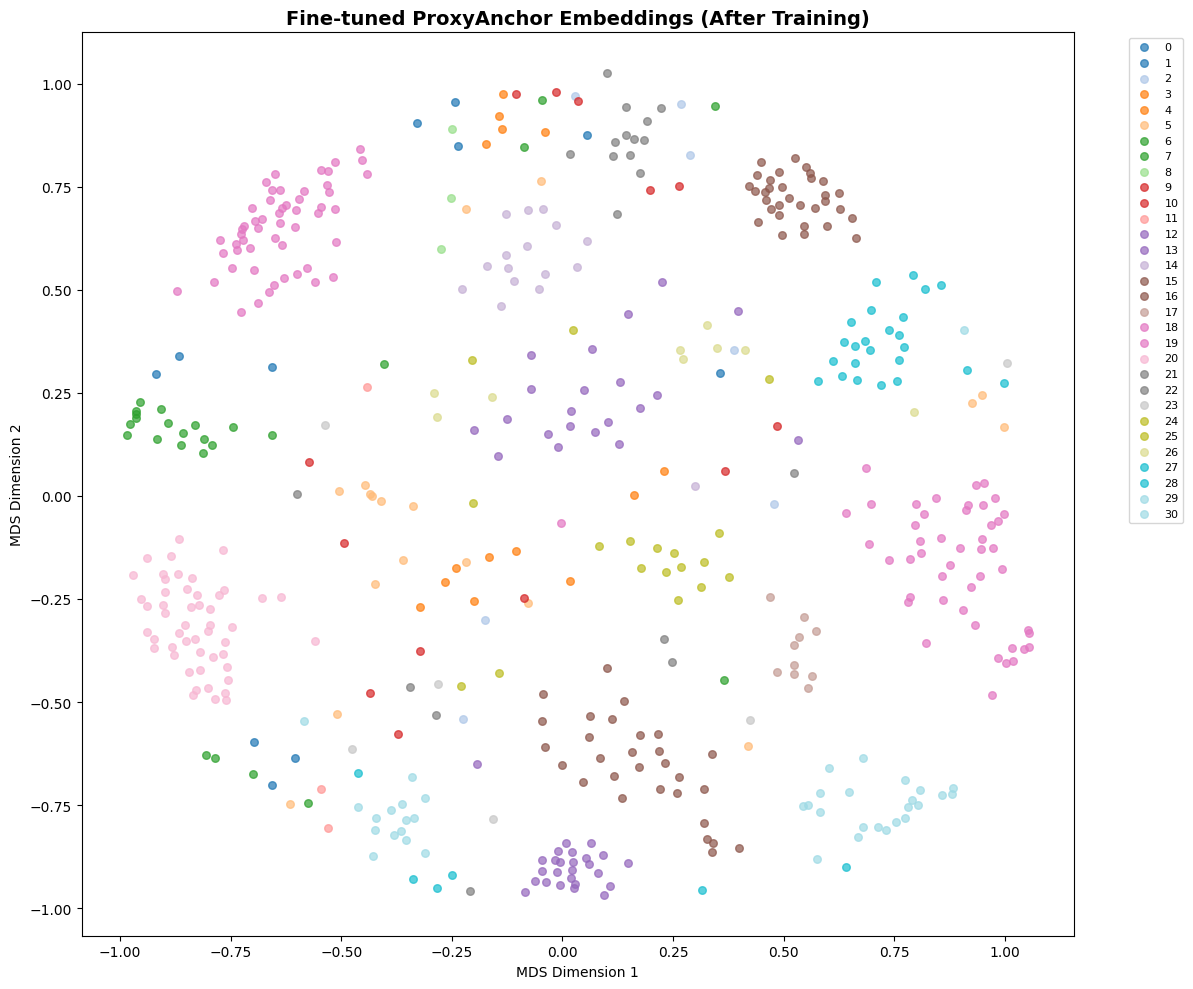

In [25]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=0,
    original_embeddings=baseline_embeddings,
    finetuned_embeddings=finetuned_embeddings,
    image_paths=image_paths,
    labels=labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_proxyanchor.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_proxyanchor": wandb.Image(fig),
    "nearest_neighbors_stats_proxyanchor": stats,
})


In [26]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss + Center Loss

In the [Loss Comparison Notebook](03_loss.ipynb), **Center Loss** showed promising results. Therefore, in this notebook we evaluate whether combining **Center Loss** with **Proxy Anchor Loss** improves the identity-balanced mAP on the validation set.


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CombinedLoss(
    first_loss=ProxyAnchorLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["proxyanchor_margin"],
        alpha=config["proxyanchor_alpha"]
    ),
    second_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Combined Loss:")
print(f"  Components: ProxyAnchorLoss + CenterLoss")
print(f"  Lambda for Center Loss: {config['proxyanchor_lambda']}")

Training components initialized:
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Combined Loss:
  Components: ProxyAnchorLoss + CenterLoss
  Lambda for Center Loss: 0.0005


In [ ]:
# Training loop
set_seeds(config['seed'])
proxy_center_checkpoint_path = CHECKPOINT_PATH / "best_proxyanchor_center.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_proxyanchor_center",
    checkpoint_path=proxy_center_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_proxyanchor_center": best_map,
    "best_epoch_proxyanchor_center": best_epoch,
    "total_epochs_proxyanchor_center": len(history['train_loss']),
    "training_time_proxyanchor_center": training_time
})

table.append([
    "Combined (ProxyAnchor + Center)",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 10.1508
  Val Loss:   8.2330
  Val mAP:    0.3227 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.2922
  Val Loss:   7.9167
  Val mAP:    0.3250 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.8419
  Val Loss:   7.6795
  Val mAP:    0.3274 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.5808
  Val Loss:   7.5469
  Val mAP:    0.3308 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.3475
  Val Loss:   0.8769
  Val mAP:    0.8863 | LR: 3.13e-06
  No improvement. Patience: 6/10

Epoch 160/200


  Train Loss: 0.3639
  Val Loss:   0.8732
  Val mAP:    0.8853 | LR: 3.13e-06
  No improvement. Patience: 7/10

Epoch 161/200


  Train Loss: 0.3565
  Val Loss:   0.8802
  Val mAP:    0.8862 | LR: 3.13e-06
  No improvement. Patience: 8/10

Epoch 162/200


  Train Loss: 0.3574
  Val Loss:   0.8734
  Val mAP:    0.8862 | LR: 3.13e-06
  No improvement. Patience: 9/10

Epoch 163/200


  Train Loss: 0.3536
  Val Loss:   0.8755
  Val mAP:    0.8865 | LR: 3.13e-06
  No improvement. Patience: 10/10

Early stopping triggered after 163 epochs

Training complete!
Best epoch: 153, Val mAP: 0.8865


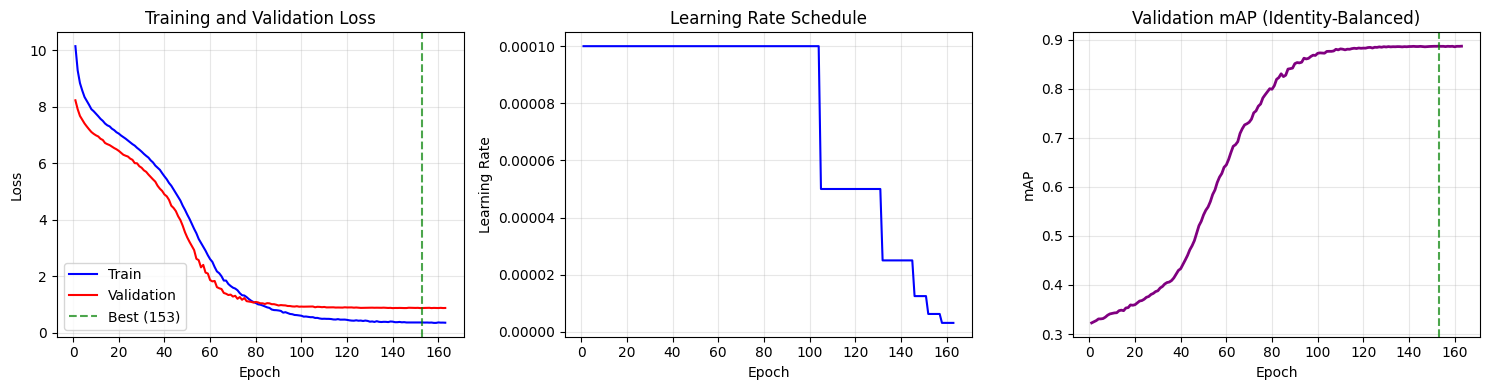

In [31]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor_center.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor_center": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(proxy_center_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 153
  Val Loss: 0.8741
  Val mAP: 0.8865


In [33]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


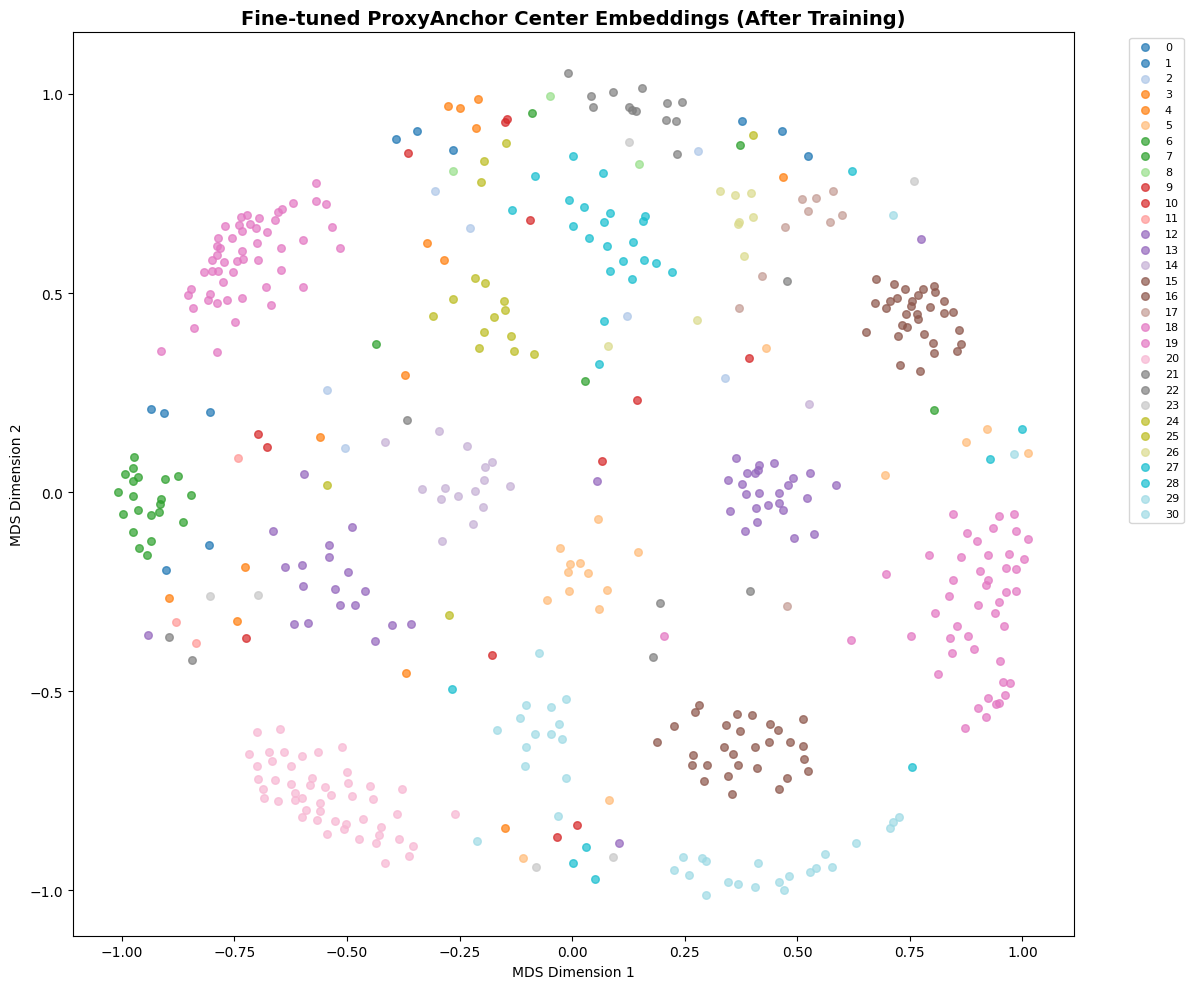

In [34]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Center Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_center_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor_center": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=0,
    original_embeddings=baseline_embeddings,
    finetuned_embeddings=finetuned_embeddings,
    image_paths=image_paths,
    labels=labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_proxyanchor_center.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_proxyanchor_center": wandb.Image(fig),
    "nearest_neighbors_stats_proxyanchor_center": stats,
})


In [35]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## ArcFace Loss + Center Loss

For additional analysis, we also evaluate how combining losses affects **ArcFace Loss**, which served as the baseline loss function prior to the [Loss Comparison Notebook](03_loss.ipynb).


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CombinedLoss(
    first_loss=ArcFaceLoss(
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        margin=config["arcface_margin"],
        scale=config["arcface_scale"]
    ),
    second_loss=CenterLoss(
        embedding_dim=config["embedding_dim"],
        num_classes=num_classes
    ),
    lambda_center=config["arcface_lambda"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Combined Loss:")
print(f"  Components: ArcFaceLoss + CenterLoss")
print(f"  Lambda for Center Loss: {config['arcface_lambda']}")

Training components initialized:
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Combined Loss:
  Components: ArcFaceLoss + CenterLoss
  Lambda for Center Loss: 0.001


In [ ]:
# Training loop
set_seeds(config['seed'])
arcface_center_checkpoint_path = CHECKPOINT_PATH / "best_arcface_center.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="combined_arcface_center",
    checkpoint_path=arcface_center_checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_arcface_center": best_map,
    "best_epoch_arcface_center": best_epoch,
    "total_epochs_arcface_center": len(history['train_loss']),
    "training_time_arcface_center": training_time
})

table.append([
    "Combined (ArcFace + Center)",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 123 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 37.1123
  Val Loss:   32.7839
  Val mAP:    0.3304 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.7586
  Val Loss:   28.4616
  Val mAP:    0.3425 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.4847
  Val Loss:   24.8342
  Val mAP:    0.3570 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 26.5793
  Val Loss:   21.9782
  Val mAP:    0.3783 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.4721
  Val Loss:   2.9664
  Val mAP:    0.8709 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 115/200


  Train Loss: 0.4661
  Val Loss:   2.9385
  Val mAP:    0.8706 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 116/200


  Train Loss: 0.4835
  Val Loss:   2.9890
  Val mAP:    0.8687 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 117/200


  Train Loss: 0.4534
  Val Loss:   2.9782
  Val mAP:    0.8733 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 118/200


  Train Loss: 0.4213
  Val Loss:   2.9403
  Val mAP:    0.8703 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 118 epochs

Training complete!
Best epoch: 108, Val mAP: 0.8739


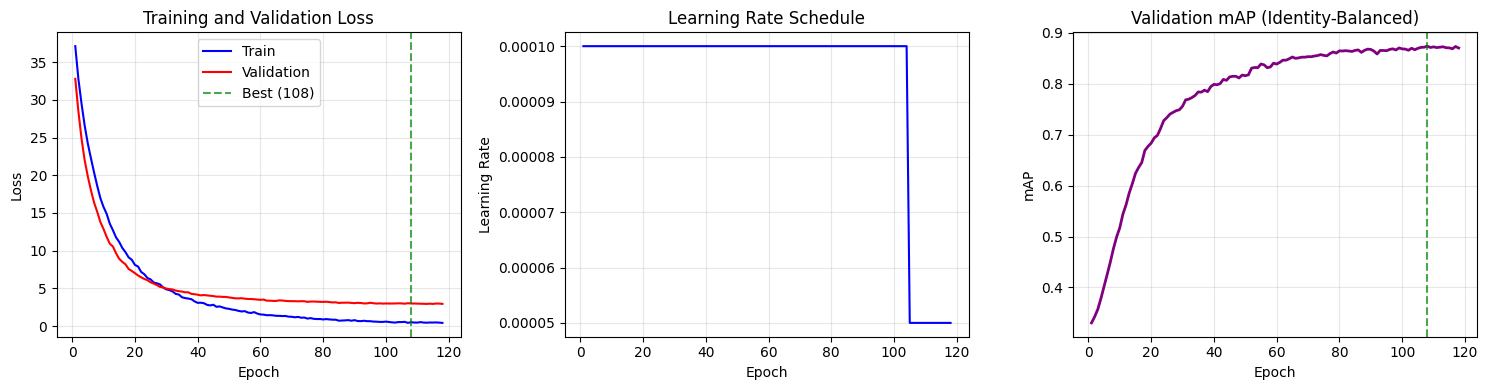

In [38]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_arcface_center.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_arcface_center": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(arcface_center_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 108
  Val Loss: 2.9906
  Val mAP: 0.8739


In [40]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


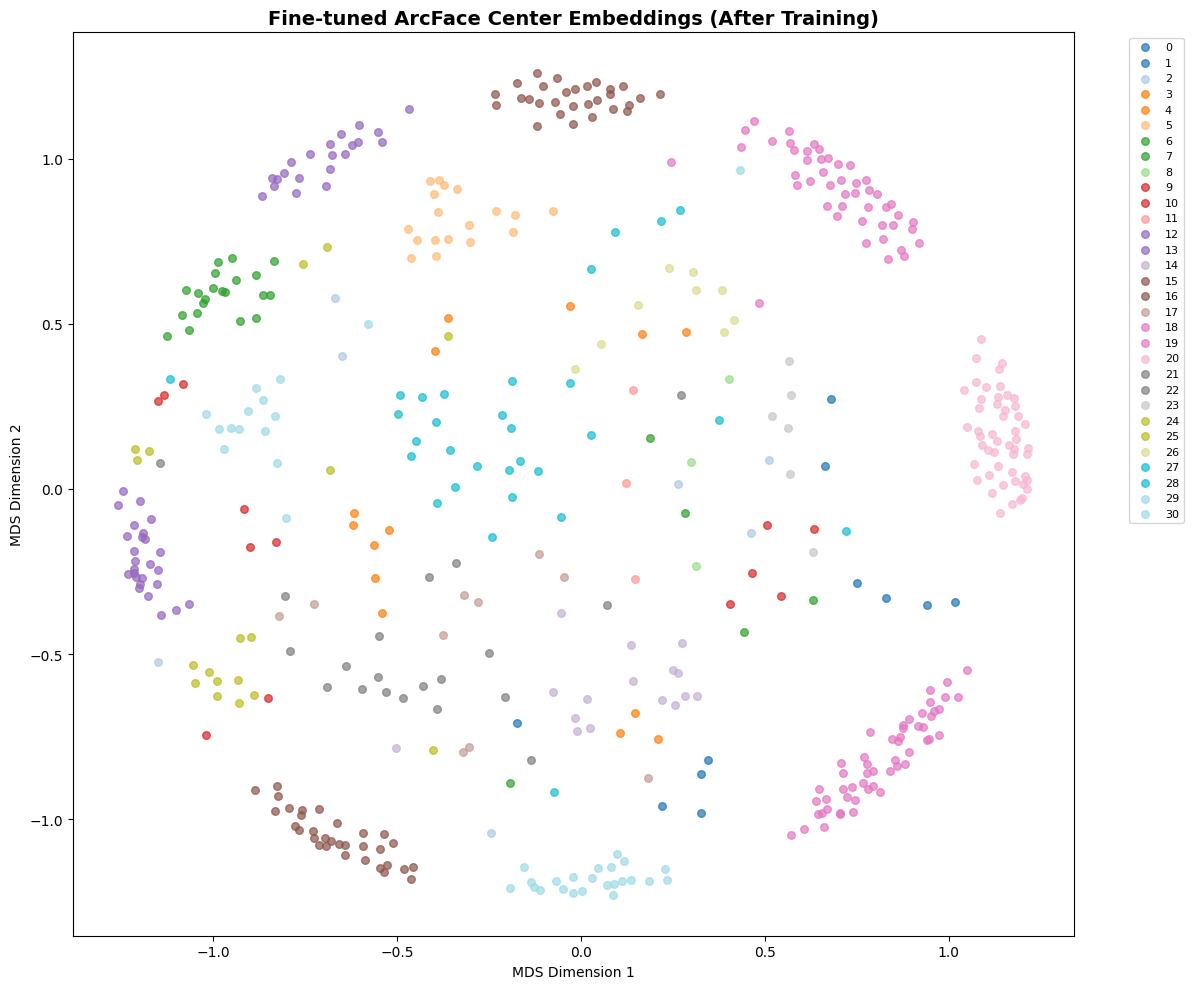

In [41]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Center Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "arcface_center_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_arcface_center": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=0,
    original_embeddings=baseline_embeddings,
    finetuned_embeddings=finetuned_embeddings,
    image_paths=image_paths,
    labels=labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_arcface_center.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_arcface_center": wandb.Image(fig),
    "nearest_neighbors_stats_arcface_center": stats,
})


In [42]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [43]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+---------------+-----------------------------------+-------------------------------+
| Loss Function   |   ProxyAnchor |   Combined (ProxyAnchor + Center) |   Combined (ArcFace + Center) |
+=================+===============+===================================+===============================+
| Best val_mAP    |      0.882174 |                          0.886509 |                      0.873894 |
+-----------------+---------------+-----------------------------------+-------------------------------+
| Best epoch      |    129        |                        153        |                    108        |
+-----------------+---------------+-----------------------------------+-------------------------------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

Result with random seed 3:
| Rank | Loss Function                     | Best val_mAP | Best Epoch |
|-----:|-----------------------------------|-------------:|-----------:|
| 1    | Combined (ProxyAnchor + Center)   | **0.920**    | 111        |
| 2    | ProxyAnchor                       | 0.916        | 140        |
| 3    | Combined (ArcFace + Center)       | 0.894        | 81         |

Result with random seed 908:
| Rank | Loss Function                     | Best val_mAP | Best Epoch |
|-----:|-----------------------------------|-------------:|-----------:|
| 1    | Combined (ArcFace + Center)       | **0.934**    | 82         |
| 2    | Combined (ProxyAnchor + Center)   | 0.929        | 144        |
| 3    | ProxyAnchor                       | 0.924        | 124        |

Result with random seed 45:
| Rank | Loss Function                     | Best val_mAP | Best Epoch |
|-----:|-----------------------------------|-------------:|-----------:|
| 1    | ProxyAnchor                       | **0.871**    | 135        |
| 2    | Combined (ProxyAnchor + Center)   | 0.863        | 145        |
| 3    | Combined (ArcFace + Center)       | 0.857        | 82         |

Result with random seed 33:
| Rank | Loss Function                     | Best val_mAP | Best Epoch |
|-----:|-----------------------------------|-------------:|-----------:|
| 1    | Combined (ProxyAnchor + Center)   | **0.893**    | 146        |
| 2    | ProxyAnchor                       | 0.891        | 136        |
| 3    | Combined (ArcFace + Center)       | 0.880        | 67         |

Result with random seed 123:
| Rank | Loss Function                     | Best val_mAP | Best Epoch |
|-----:|-----------------------------------|-------------:|-----------:|
| 1    | Combined (ProxyAnchor + Center)   | **0.887**    | 153        |
| 2    | ProxyAnchor                       | 0.882        | 129        |
| 3    | Combined (ArcFace + Center)       | 0.874        | 108        |

| Rank | Loss Function                       | Seed 3 | Seed 908 | Seed 45 | Seed 33 | Seed 123 | **Mean mAP** | **Std** |
| ---: | ----------------------------------- | -----: | -------: | ------: | ------: | -------: | -----------: | ------: |
|    1 | **Combined (ProxyAnchor + Center)** |  0.920 |    0.929 |   0.863 |   0.893 |    0.887 |    **0.898** |   0.027 |
|    2 | **ProxyAnchor**                     |  0.916 |    0.924 |   0.871 |   0.891 |    0.882 |    **0.897** |   0.020 |
|    3 | **Combined (ArcFace + Center)**     |  0.894 |    0.934 |   0.857 |   0.880 |    0.874 |    **0.888** |   0.032 |

Short interpretation

Combined (ProxyAnchor + Center) achieves the highest average mAP (0.898) across seeds and is very competitive in every run.

ProxyAnchor alone is close behind (0.897 mean mAP) and shows slightly lower variance, making it highly reliable.

Combined (ArcFace + Center) reaches strong peak values (0.934), but its mean is slightly lower and variance slightly higher.

Conclusion: Combining ProxyAnchor with Center Loss provides the best trade-off between peak performance and stability, while plain ProxyAnchor is nearly as strong and slightly more consistent.

## Submission

In [ ]:
submission_model = "proxyanchor"

submission_dict = {
    "proxyanchor": proxy_anchor_checkpoint_path,
    "proxy_center": proxy_center_checkpoint_path,
    "arcface_center": arcface_center_checkpoint_path,
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:00<00:00,  5.00s/it]

Test embeddings shape: (371, 768)


In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 29986.19it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9962
  Mean: 0.0686
  Std: 0.1402


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.480112
1       1    0.154116
2       2    0.209182
3       3    0.201412
4       4    0.156037
5       5    0.029254
6       6    0.000000
7       7    0.078033
8       8    0.263681
9       9    0.076456



Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/backbone/submission.csv
File size: 1802.3 KB


## Artifacts

In [ ]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"{key}-model",
        type="model",
        description="Fine-tuned MegaDescriptor model for jaguar re-identification with loss: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_bg_image,▁
best_epoch_blur_bg,▁
best_epoch_const_bg,▁
best_epoch_extend_fg,▁
best_epoch_noise_bg,▁
best_epoch_sample_fg,▁
epoch,▃▄▅▅▇▁▂▂▄▄▅▆▇▇█▂▂▃▃▄▅▅▇█▁▂▃▃▇▇▁▃▆▇▁▆▇▄▄▆
final_val_mAP_baseline,▁
final_val_mAP_bg_image,▁
+21,...


Public submission score for seed 12 and blur version: 0.714